In [100]:
!pip3 install seaborn --break-system-packages
!pip3 install matplotlib --break-system-packages


In [126]:

import seaborn as sns

titanic_dataframe = sns.load_dataset('titanic')

titanic_dataframe.head(10)



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [127]:
#print info
titanic_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:


#stastical information
titanic_dataframe.describe()

#shape of the dataframe
titanic_dataframe.shape

In [102]:
titanic_dataframe['fare'].sort_values(ascending=False).head(30)

258    512.3292
737    512.3292
679    512.3292
88     263.0000
27     263.0000
341    263.0000
438    263.0000
311    262.3750
742    262.3750
118    247.5208
299    247.5208
557    227.5250
700    227.5250
380    227.5250
716    227.5250
527    221.7792
377    211.5000
730    211.3375
779    211.3375
689    211.3375
318    164.8667
856    164.8667
268    153.4625
332    153.4625
609    153.4625
498    151.5500
305    151.5500
297    151.5500
708    151.5500
195    146.5208
Name: fare, dtype: float64

In [103]:
#percentage of null values in each colom
missing_values = titanic_dataframe.isnull().sum() / len(titanic_dataframe) * 100
print(f"Missing values in each colom \n\n{missing_values}")

Missing values in each colom 

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [104]:

#save the loaded DataFrame as a committed offline fallback
# saving the data to csv file from dataframe.
titanic_dataframe.to_csv("titanic.csv", index=False)

# 2 Apply missing-value handling

In [105]:
#iterate over the missing values result.
coloms_with_null_less_5 = []
for name, value in missing_values.items():
    if value <= 5 and value != 0:
        print(f"name {name} : value {value}")
        coloms_with_null_less_5.append(name)



name embarked : value 0.22446689113355783
name embark_town : value 0.22446689113355783


# Under 5% missing → drop those rows;

In [106]:
#under 5% missing → drop those rows;
# here embarked,embark_town two coloms are less then 5, so we need to drop off null rows.

print(coloms_with_null_less_5)
for null_coloum in coloms_with_null_less_5:
    titanic_dataframe.dropna(subset=[null_coloum], inplace=True)

#verify are there any null rows in embarked colom
titanic_dataframe[titanic_dataframe['embarked'].isna()]
#verify are there any null rows in embark_town colom
titanic_dataframe[titanic_dataframe['embark_town'].isna()]




['embarked', 'embark_town']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


# 5%–30% missing → impute

In [107]:
#iterate over the missing values result.
coloms_with_null_less_30 = []
for name, value in missing_values.items():
    if value > 5 and value <= 30:
        print(f"name {name} : value {value}")
        coloms_with_null_less_30.append(name)

coloms_with_null_less_30

name age : value 19.865319865319865


['age']

In [108]:
#imputing the missing values with median since it is numberic in the 'age' colom
titanic_dataframe['age'] = titanic_dataframe['age'].fillna(titanic_dataframe['age'].median())

In [109]:
#verifying the null values in the 'age' colom
titanic_dataframe[titanic_dataframe['age'].isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


# Reason for dropping the deck colom
## 1)more than 50% null values will create the noise in the data.
## 2)if we drop the 77% of data which is null, can be a huge data loss.
## 3)imputing the mojarity of the data with imaginative data is not correct which will misslead the model. 

In [155]:
titanic_dataframe = titanic_dataframe.drop(columns=['deck'])

In [156]:
titanic_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 79.4 KB


# Justificatoin:

### The reason for dropping the null rows for embarked and embark_town coloms, since the volumne of null values 

### The reason for imputing the null values in the age colom is again volumn and data type is numaric. Along with that there is not much bias will be introduced when we are imputing the less than 20% data. 

### Reason for dropping the deck colom is majority of the row are null 77%. 

# 3 Univariate analysis: Plots:

### plot a histogram and a box plot for both age and fare

# Histogram plot for Age

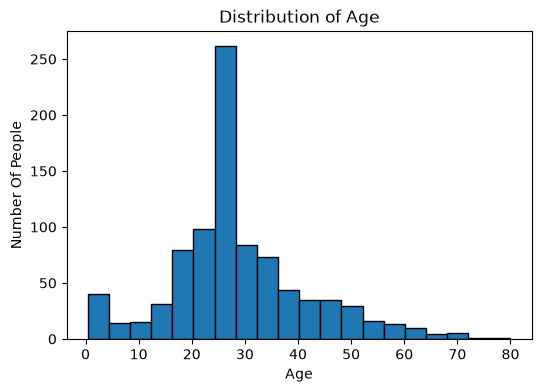

In [112]:
#histogram plot for age
import matplotlib.pyplot as plt

#below methos will deside the size of the diagram in the editor
plt.figure(figsize=(6,4))
#bins parameter will deside number of bars that are required to show 
#edgecolor will give the seperation between each bar.
plt.hist(titanic_dataframe['age'], bins=20, edgecolor='black')

#title for the diagram
plt.title('Distribution of Age')
#X - Axis represents the age of the passenger
plt.xlabel("Age")

#Y - Axis represents the number of people in that age group
plt.ylabel("Number Of People")

#displaying the graph on the console
plt.show()





# Histogram plot for fare

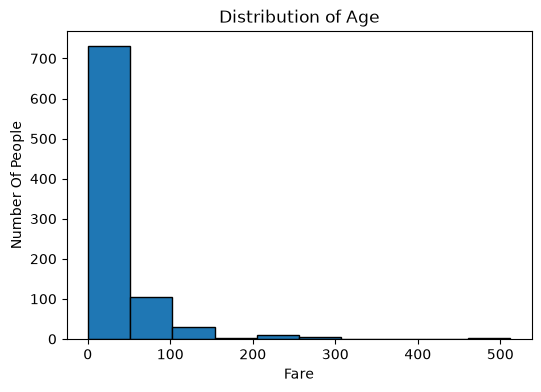

In [113]:
#histogram plot for age
import matplotlib.pyplot as plt

#below methos will deside the size of the diagram in the editor
plt.figure(figsize=(6,4))
#bins parameter will deside number of bars that are required to show 
#edgecolor will give the seperation between each bar.
plt.hist(titanic_dataframe['fare'], bins=10, edgecolor='black')

#title for the diagram
plt.title('Distribution of Age')
#X - Axis represents the fare of the ticket
plt.xlabel("Fare")

#Y - Axis represents the number of people in that with that fare
plt.ylabel("Number Of People")

#displaying the graph on the console
plt.show()

# Using the IQR rule (outliers are points outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR]), report how many outliers each column has. 

# Outliers can calculated for only numberic coloms

In [114]:
# formula for outliers
# Lower Bound=Q1−1.5×IQR
# Upper Bound=Q3+1.5×IQR

# Q1 = titanic_dataframe['colom_name'].quantile(0.25)
# Q3 = titanic_dataframe['colom_name'].quantile(0.75)
# IQR = Q3 - Q1

In [129]:
# get the numberic coloms

numberic_columns = titanic_dataframe.select_dtypes(include=['number']).columns

print(f"Numeric columns : {numberic_columns}")

Numeric columns : Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')


In [137]:
outlier_counts = {}

for numberic_column in numberic_columns:
    Q1 = titanic_dataframe[numberic_column].quantile(0.25)
    Q3 = titanic_dataframe[numberic_column].quantile(0.75)
    IQR = Q3 - Q1
    print(f"column name {null_coloum} and the IQR {IQR}")

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")

    #creating the dictionary with outliers
    outlier_counts[numberic_column] = ((titanic_dataframe[numberic_column] < lower_bound) 
    | (titanic_dataframe[numberic_column] > upper_bound)).sum()

#displaying the outliers count for all coloums
for column, count in outlier_counts.items():
    print(f"{column}: {count} outliers")


column name embark_town and the IQR 1.0
Lower Bound : -1.5
Upper Bound : 2.5
column name embark_town and the IQR 1.0
Lower Bound : 0.5
Upper Bound : 4.5
column name embark_town and the IQR 17.875
Lower Bound : -6.6875
Upper Bound : 64.8125
column name embark_town and the IQR 1.0
Lower Bound : -1.5
Upper Bound : 2.5
column name embark_town and the IQR 0.0
Lower Bound : 0.0
Upper Bound : 0.0
column name embark_town and the IQR 23.0896
Lower Bound : -26.724
Upper Bound : 65.6344
survived: 0 outliers
pclass: 0 outliers
age: 11 outliers
sibsp: 46 outliers
parch: 213 outliers
fare: 116 outliers


# Compute mean, median, and mode for fare, and state in writing whether its distribution is right-skewed, left-skewed, or symmetric, referencing the mean/median/mode ordering.

In [149]:
fare_mean = titanic_dataframe['fare'].mean()
fare_median = titanic_dataframe['fare'].median()
fare_mode = titanic_dataframe['fare'].mode()[0]

print(f"fare_mean : {fare_mean:.2f} and fare_median : {fare_median:.2f} and fare_mode : {fare_mode:.2f}")

fare_mean : 32.20 and fare_median : 14.45 and fare_mode : 8.05


# Justification
 ## Mean = 32.20
 ## Median = 14.45
 ## Mode = 8.05

 #### Mean (32.20) > Median (14.45) > Mode (8.05)

 ##### This indicates the fare distribution is right-skewed(positively skewed).
 ##### Beacause the mean is pulled upward, since very small number of passengers paid very high aount to the ticket.

# 4 Bivariate analysis: using boolean masking (with &/| combinations), compute and report survival rate broken down by (a) sex

In [173]:
male_passengers = titanic_dataframe['sex'] == 'male'
survived_passengers = titanic_dataframe['survived'] == 1

male_survived_passengers  = male_passengers & survived_passengers


total_male_passengers = titanic_dataframe[male_passengers].shape[0]
print(f"Total Male passengers : {total_male_passengers}")


total_male_survivors = titanic_dataframe[male_survived_passengers].shape[0]
print(f"Total Male Survivors : {total_male_survivors}")

male_survival_rate = (total_male_survivors / total_male_passengers) * 100

print(f"Male survivel rate is : {male_survival_rate:.2f}")

Total Male passengers : 577
Total Male Survivors : 109
Male survivel rate is : 18.89


# (b) pclass, and (c) sex and pclass together. Then compute a correlation matrix restricted to exactly these six columns: survived, pclass, age, sibsp, parch, and fare — the dataset's numeric columns, including survived (0/1-valued) as the natural numeric target. Exclude the boolean-typed columns adult_male and alone from the correlation matrix: they are derived/redundant flags (directly computable from sex/age and from sibsp+parch respectively), not independent measured features. Render the resulting 6×6 matrix as a heatmap using sns.heatmap, with a short written interpretation of the two strongest correlations you observe — defined precisely as the two feature pairs with the largest absolute off-diagonal correlation coefficients (rank all off-diagonal pairs by abs(correlation) and take the top two).